In [78]:
%load_ext autoreload 
%autoreload 2
import xarray as xr
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy.stats import binned_statistic
from src.loading import (
    SATURATED_MAXPR_MIN,
    load_gpm_feature_stats,
    load_imerg_feature_stats,
    load_dyamond_feature_stats,
    load_archived_dyamond_feature_stats,
     load_pickled_archived_features
)
from src.plotting import (
    source_line_params,
    array_midpoints,
    discrete_cmap,
    plot_mean_stat,
    gpm_area_factor,
    gpm_area_factor_accurate,
)
from src.saving import save_figure

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load feature data
By default, no thresholding on $P_{max}$, feature perimeter-on-edge fraction, or size is applied. 

In [85]:
# Load the 0.05º gridded precipitation
_RES = "0p05"
_ACCUM = "15min"

feature_stats_dict_0p05 = {
    'GPM': load_gpm_feature_stats(threshold=1.0, res=_RES),
    'GEOS': load_dyamond_feature_stats(
        'GEOS-3km', accum=_ACCUM, res=_RES
    ),
    'gSAM': load_dyamond_feature_stats(
        'gSAM-4km', accum=_ACCUM, res=_RES
    ),
    'ICON': load_dyamond_feature_stats(
        'ICON-SAP-5km', accum=_ACCUM, res=_RES
    ),
    'MPAS': load_dyamond_feature_stats(
        'MPAS-3km', accum=_ACCUM, res=_RES
    ),
    'SCREAM': load_dyamond_feature_stats(
        'SCREAM-3km', accum=_ACCUM, res=_RES
    ),
    'SHiELD': load_dyamond_feature_stats(
        'SHiELD-3km', accum=_ACCUM, res=_RES
    )
}

for name, df in feature_stats_dict_0p05.items():
    print(f"{name:>8}: {df.height:,} rows")

     GPM: 195,648 rows
    GEOS: 969,156 rows
    gSAM: 770,869 rows
    ICON: 1,140,060 rows
    MPAS: 417,551 rows
  SCREAM: 1,764,297 rows
  SHiELD: 770,803 rows


# Plot CDFs of $P_{max}$

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/Pmax_CDF.pdf as PDF ...


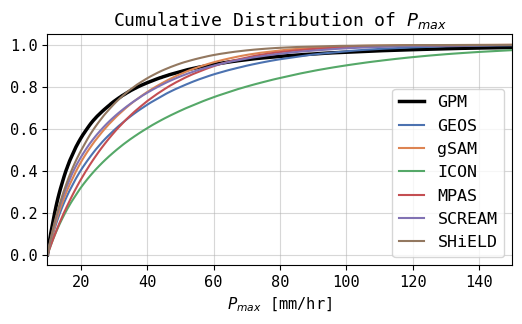

In [83]:
def _plot_cdf(series: pl.Series, ax: plt.Axes = None, label: str = None, **kwargs):
    values = series.drop_nulls().sort().to_numpy()
    cdf = np.arange(1, len(values) + 1) / len(values)
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.get_figure()
    ax.plot(values, cdf, label=label, **kwargs)
    return fig, ax

_EDGE_FRAC_MAX = 0.05
_MAX_PRECIP_MIN = 10.0
_SIZE_PX_MIN = 5
p95_stats = {}
fig, ax = plt.subplots(figsize=(6,3))
for source, df in feature_stats_dict_0p05.items():
    df = df.filter(
        pl.col("max_precip_mm_hr") >= _MAX_PRECIP_MIN,
        pl.col("cross_track_edge_px") / pl.col("perimeter_px") <= _EDGE_FRAC_MAX,
        pl.col("size_px") >= _SIZE_PX_MIN
    )

    p95_stats[source] = df['max_precip_mm_hr'].quantile(0.95)

    _plot_cdf(
        df['max_precip_mm_hr'], 
        ax=ax,
        label=source,
        **source_line_params(source)
    )

ax.set_xlim(10, 150)
ax.set_xlabel('$P_{max}$ [mm/hr]')
ax.legend()
ax.grid(alpha=0.5)
ax.set_title('Cumulative Distribution of $P_{max}$')
save_figure(fig, 'Pmax_CDF.pdf')


Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/p95_bar_plot.pdf as PDF ...


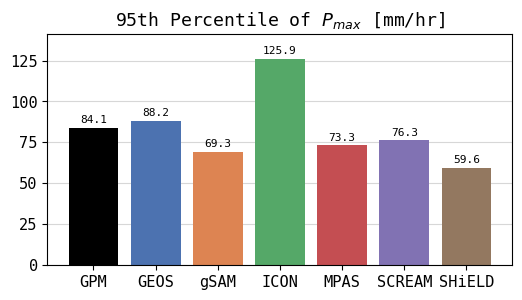

In [84]:
fig, ax = plt.subplots(figsize=(6,3))
bars = ax.bar(
    list(p95_stats.keys()),
    list(p95_stats.values()),
    color=[source_line_params(s)['color'] for s in p95_stats]
)
ax.set_title('95th Percentile of $P_{max}$ [mm/hr]')
ax.grid(axis='y', alpha=0.5)
ax.set_axisbelow(True)
ax.bar_label(bars, fmt='%.1f', padding=2, fontsize=8)
ax.margins(y=0.12)
save_figure(fig, 'p95_bar_plot.pdf')

# Size distribution

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/PDF_PF_Area.pdf as PDF ...


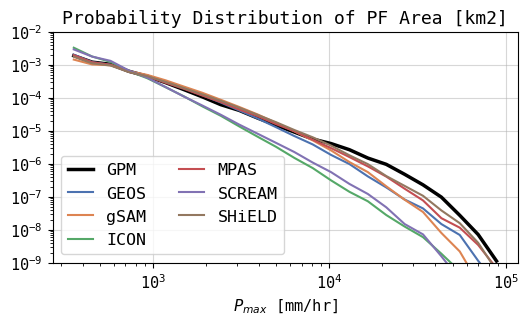

In [81]:
def _plot_pdf(
    series: pl.Series,
    bins,
    ax: plt.Axes = None,
    label: str = None,
    **kwargs,
):
    values = series.drop_nulls().to_numpy()

    pdf, edges = np.histogram(values, bins=bins, density=True)
    bin_centers = np.sqrt(edges[:-1] * edges[1:])

    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.get_figure()

    ax.plot(bin_centers, pdf, label=label, **kwargs)

    return fig, ax


_EDGE_FRAC_MAX = 0.05
_MAX_PRECIP_MIN = 10.0
_SIZE_PX_MIN = 5
fig, ax = plt.subplots(figsize=(6,3))
for source, df in feature_stats_dict_0p05.items():
    df = df.filter(
        pl.col("max_precip_mm_hr") >= _MAX_PRECIP_MIN,
        pl.col("cross_track_edge_px") / pl.col("perimeter_px") <= _EDGE_FRAC_MAX,
        pl.col("size_px") >= _SIZE_PX_MIN
    )

    _plot_pdf(
        df['area_km2'], 
        ax=ax,
        label=source,
        bins=np.logspace(2.5, 5.0, 25),
        **source_line_params(source)
    )

ax.set_xlabel('$P_{max}$ [mm/hr]')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(ncols=2)
ax.grid(alpha=0.5)
ax.set_ylim(1e-9, 1e-2)
ax.set_title('Probability Distribution of PF Area [km2]')
save_figure(fig, 'PDF_PF_Area.pdf')

Text(0.5, 1.0, 'Cumulative Distribution of $P_{max}$')

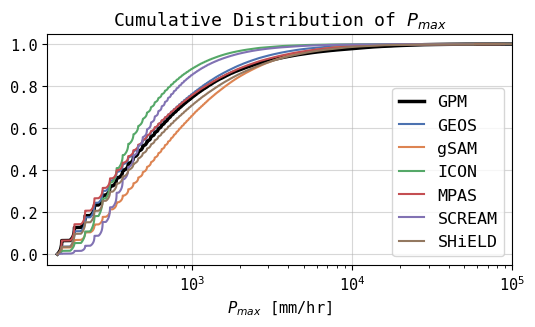

In [82]:
def _plot_cdf(series: pl.Series, ax: plt.Axes = None, label: str = None, **kwargs):
    values = series.drop_nulls().sort().to_numpy()
    cdf = np.arange(1, len(values) + 1) / len(values)
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.get_figure()
    ax.plot(values, cdf, label=label, **kwargs)
    return fig, ax

_EDGE_FRAC_MAX = 0.05
_MAX_PRECIP_MIN = 10.0
_SIZE_PX_MIN = 5
fig, ax = plt.subplots(figsize=(6,3))
for source, df in feature_stats_dict_0p05.items():
    df = df.filter(
        pl.col("max_precip_mm_hr") >= _MAX_PRECIP_MIN,
        pl.col("cross_track_edge_px") / pl.col("perimeter_px") <= _EDGE_FRAC_MAX,
        pl.col("size_px") >= _SIZE_PX_MIN
    )

    _plot_cdf(
        df['area_km2'], 
        ax=ax,
        label=source,
        **source_line_params(source)
    )

ax.set_xlabel('$P_{max}$ [mm/hr]')
ax.set_xscale('log')
ax.set_xlim(10**2.1, 1e5)
ax.legend()
ax.grid(alpha=0.5)
ax.set_title('Cumulative Distribution of $P_{max}$')


# Sensitivity Sweeps

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensitivity/Area_PDF_EFM_Sweep_GPM-DYAMOND.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensitivity/Area_PDF_EFM_Sweep_IMERG-DYAMOND.pdf as PDF ...


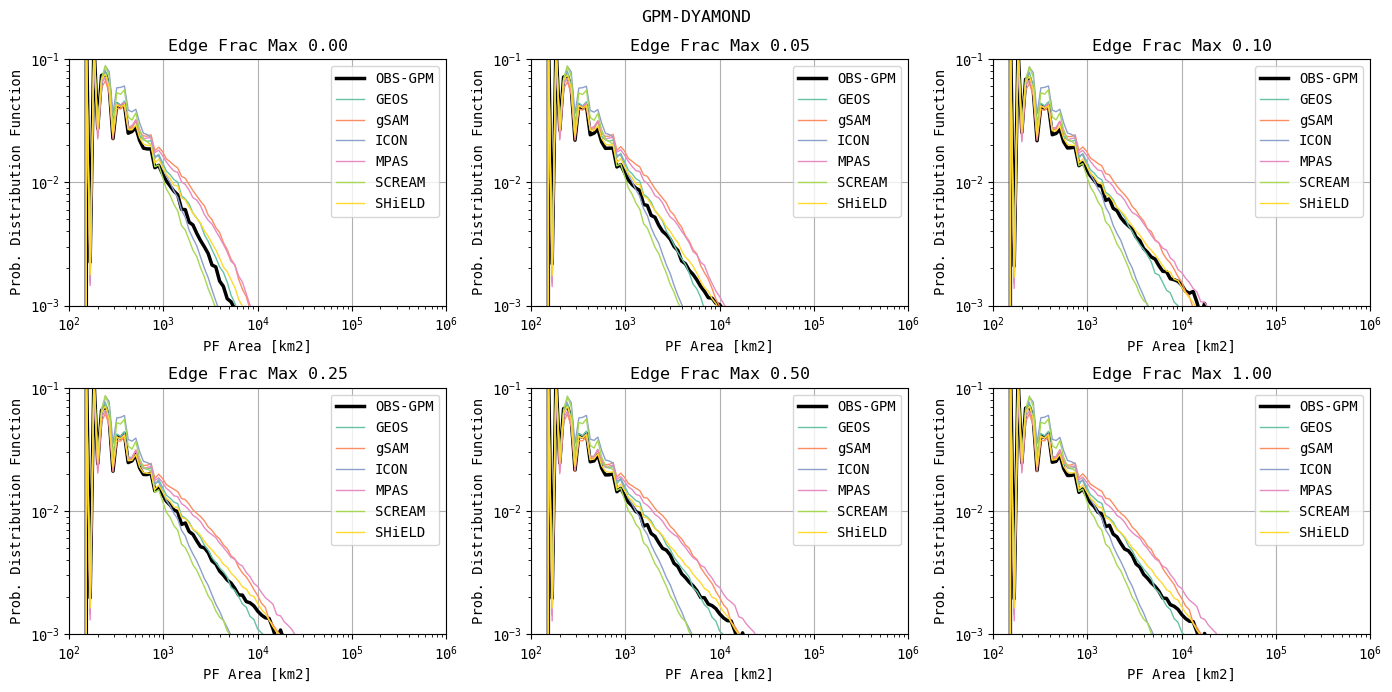

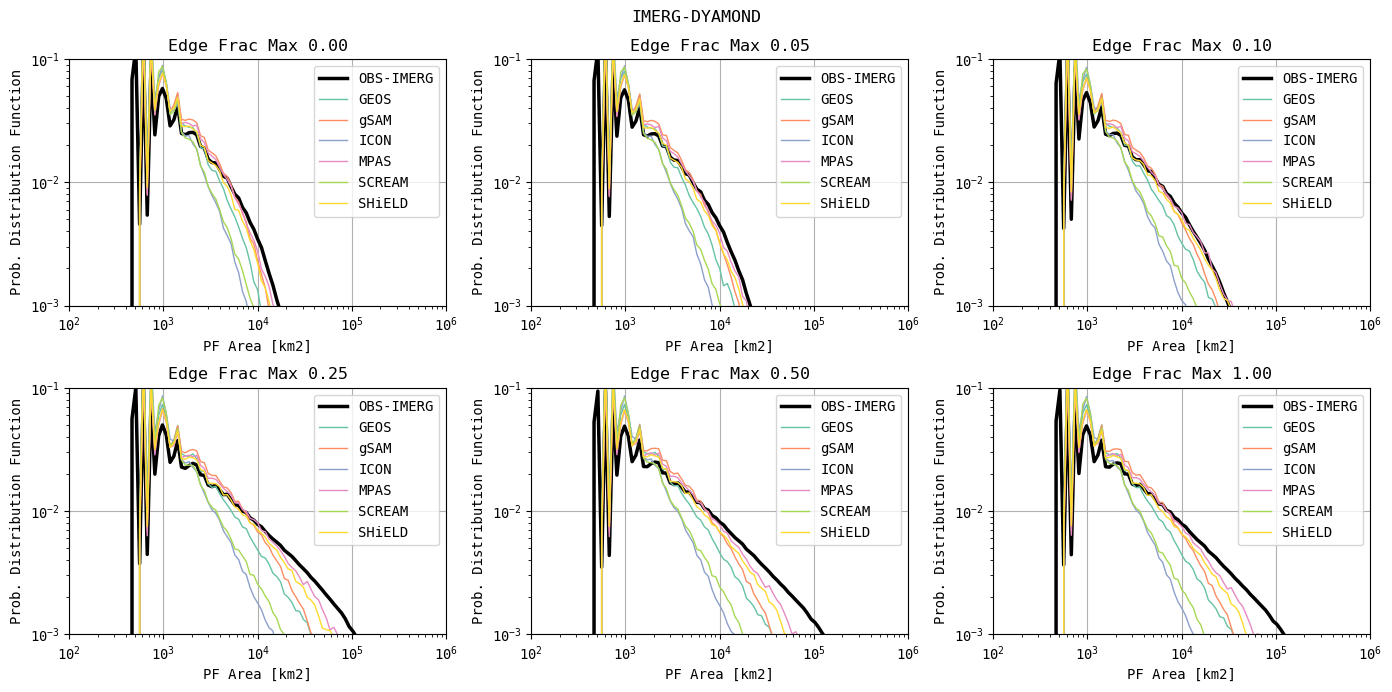

In [4]:
def _get_source_line_params(source):
    if 'OBS' in source:
        color='black'
        lw = 2.5
        linestyle='solid'
    else:
        color=None
        lw = 1.0
        linestyle='solid'
    return {'color': color, 'lw': lw, 'linestyle': linestyle}

for experiment, feature_stats_dict in Feature_Data_Dict.items():
    # Make the plot
    fig, axs = plt.subplots(
        nrows=2,
        ncols=3,
        figsize=(14,7)
    )
    fig.suptitle(experiment)

    _EDGE_FRAC_MAX_LIST =  [0.0, 0.05, 0.1, 0.25, 0.5, 1.0]
    for ax, _EDGE_FRAC_MAX in zip(axs.ravel(), _EDGE_FRAC_MAX_LIST):
        for source, df in feature_stats_dict.items():
            df = df.filter(
                pl.col("cross_track_edge_px") / pl.col("perimeter_px") <= _EDGE_FRAC_MAX
            )
            
            bins = np.logspace(2, 6, 100)
            counts = binned_statistic(
                df['area_km2'],
                None,
                'count', 
                bins=bins
            ).statistic
            pdf = counts / counts.sum()

            line_params = _get_source_line_params(source)
            ax.plot(
                array_midpoints(bins),
                pdf,
                label=source,
                color=line_params['color'],
                lw=line_params['lw'],
                linestyle=line_params['linestyle']
            )

        ax.set_xscale('log')
        ax.legend()
        ax.grid()
        ax.set_ylim(1e-3, 1e-1)
        ax.set_xlim(1e2, 1e6)
        ax.set_yscale('log')
        ax.set_xlabel('PF Area [km2]')
        ax.set_ylabel('Prob. Distribution Function')
        ax.set_title(f'Edge Frac Max {_EDGE_FRAC_MAX:.2f}')

    fig.tight_layout(pad=1.0)
    save_figure(fig, name=f'/sensitivity/Area_PDF_EFM_Sweep_{experiment}.pdf')